## Exploration of Climsim Dynamics


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import numpy as np
import os
import re
from tqdm import tqdm

import gcsfs
import datetime as dt
import cftime
import json
import fsspec
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'

fs = gcsfs.GCSFileSystem()
fs.ls("gs://leap-persistent-ro/sungdukyu") # List files in the bucket where the E3SM-MMF dataset is stored

['leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.grid-info.zarr',
 'leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.train.input.zarr',
 'leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.train.output.zarr',
 'leap-persistent-ro/sungdukyu/testing']

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from climsim_training_utils import *

In [4]:
ds_in, ds_out = load_raw_dataset(chunks=False)

In [5]:
ds_input, ds_output = process_climsim(ds_in, ds_out, downsample=False)

ds_input

<xarray.Dataset> Size: 80GB
Dimensions:      (time: 210240, lev: 60, ncol: 384)
Coordinates:
  * time         (time) object 2MB 0001-02-01 00:00:00 ... 0009-01-31 23:40:00
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: lev
Data variables:
    state_t      (time, lev, ncol) float64 39GB ...
    state_q0001  (time, lev, ncol) float64 39GB ...
    state_ps     (time, ncol) float64 646MB ...
    pbuf_SOLIN   (time, ncol) float64 646MB ...
    pbuf_LHFLX   (time, ncol) float64 646MB ...
    pbuf_SHFLX   (time, ncol) float64 646MB ...
Attributes:
    calendar:  NO_LEAP
    fv_nphys:  2
    ne:        4

In [15]:
cloud_temp = ds_output.isel(lev=59, time=slice(150000, 200000)).state_t
GCM_temp = ds_input.isel(lev=59, time=slice(150001, 200001)).state_t

In [18]:
GCM_temp.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array(cftime.DatetimeNoLeap(6, 10, 17, 8, 20, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 8B 0006-10-17 08:20:00

In [19]:
cloud_temp.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array(cftime.DatetimeNoLeap(6, 10, 17, 8, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 8B 0006-10-17 08:00:00

In [20]:
(GCM_temp.shift(time=-1) - cloud_temp).mean() # how much atmosphere macro temp changes within GCM

<xarray.DataArray 'state_t' ()> Size: 8B
array(0.07468116)

In [13]:
(cloud_temp - GCM_temp).mean() # how much on average cloud changes temp

<xarray.DataArray 'state_t' ()> Size: 8B
array(-0.07464282)

In [39]:
qG = ds_input.isel(lev=34, ncol=59, time=slice(100, 106))
qC = ds_output.isel(lev=34, ncol=59, time=slice(100, 106))

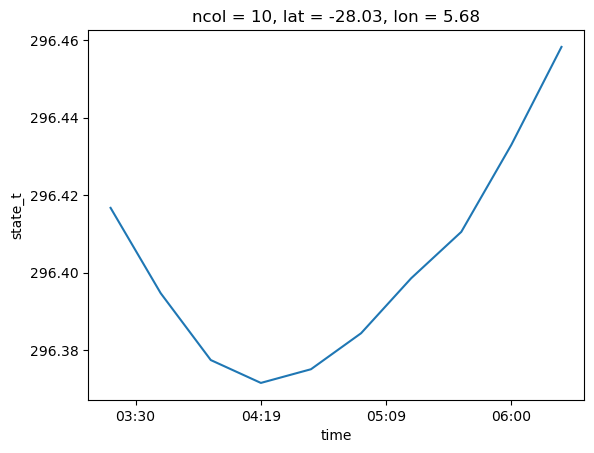

In [30]:
qC.state_t.plot()

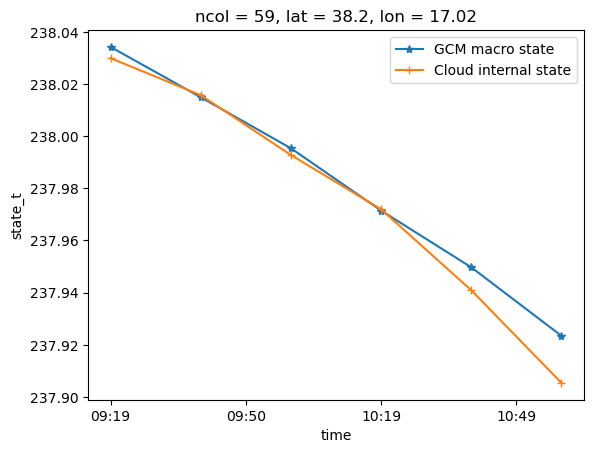

In [40]:
qG.state_t.plot(marker='*', label='GCM macro state')
qC.state_t.plot(marker='+', label='Cloud internal state')
plt.legend()


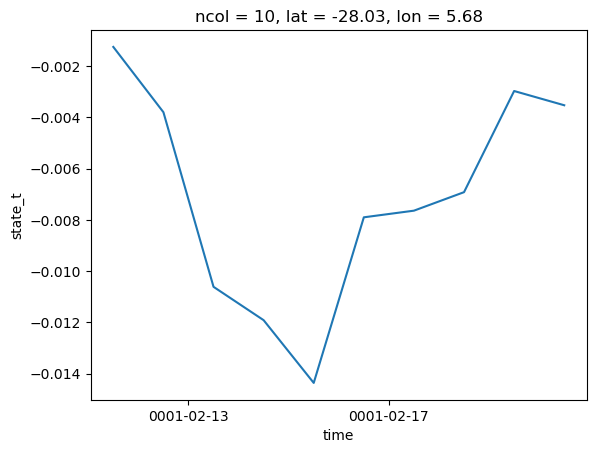

In [21]:
(qC.state_t - qG.state_t).plot()

In [11]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    # use .load() or .compute() to do the math and get the daily mean data
    ds_input.load()
    ds_output.load()

[########################################] | 100% Completed | 10m 49s
[########################################] | 100% Completed | 21m 38s


In [23]:
def ds_to_npy(ds, load=True):
    ds = ds.stack({'sample' : ['time', 'ncol']}) # stacks the time and ncol into one MultiIndex
    ds = ds.to_stacked_array('mlvar', sample_dims=['sample']) # turns the data array of multiple vars into one stacked var
    return(ds.values)

In [24]:
X, Y = ds_to_npy(ds_input), ds_to_npy(ds_output)

In [28]:
user_path = "gs://leap-scratch/sammyagrawal"  # 👀 make sure to prepend `gs://` to the path or xarray will interpret this as a local path
#store_name = "processed_store.zarr"
#ds_processed.to_zarr(f"{user_path}/{store_name}")

with fs.open(os.path.join(user_path, "input_climsim.npy"), 'wb') as f:
    np.save(f, X)

with fs.open(os.path.join(user_path, "output_climsim.npy"), 'wb') as f:
    np.save(f, Y)

In [29]:
fs.ls(user_path)

['leap-scratch/sammyagrawal/input_climsim.npy',
 'leap-scratch/sammyagrawal/output_climsim.npy']

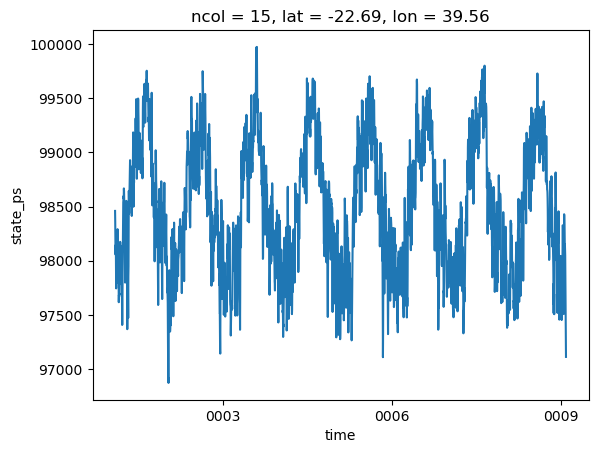

In [21]:
ds_input.state_ps.isel(ncol=15).plot()

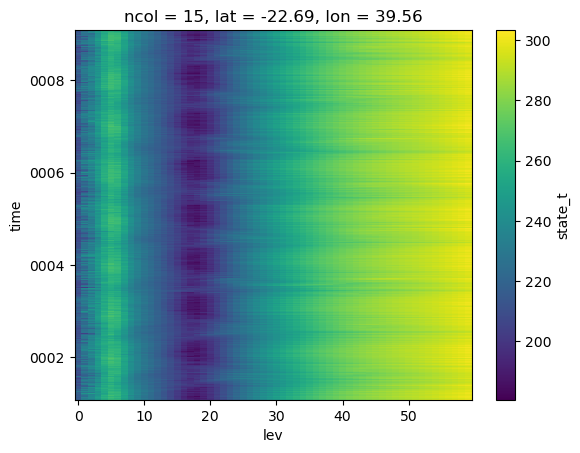

In [22]:
ds_input.state_t.isel(ncol=15).plot()

In [ ]:
# to test
user_path = "gs://leap-scratch/sammyagrawal"
with fs.open(os.path.join(user_path, "input_climsim.npy"), 'rb') as f:
    x_npy = np.load(f)
with fs.open(os.path.join(user_path, "output_climsim.npy"), 'rb') as f:
    y_npy = np.load(f)

In [2]:
from utils import *

In [4]:
%%time
ds_input, ds_output = reconstruct_xarr_from_npy()

Loading saved numpy arrays
Finished Loading
Computed time 2920
CPU times: user 12.1 s, sys: 3.34 s, total: 15.5 s
Wall time: 1min 8s


In [5]:
ds_input

<xarray.Dataset> Size: 1GB
Dimensions:              (time: 2920, ncol: 384, mli: 124)
Coordinates:
  * time                 (time) object 23kB 0001-02-01 12:00:00 ... 0009-01-3...
  * ncol                 (ncol) int64 3kB 0 1 2 3 4 5 ... 379 380 381 382 383
    variable             (mli) object 992B 'state_t' 'state_t' ... 'pbuf_SHFLX'
    lev                  (mli) object 992B 0 1 2 3 4 5 ... 58 59 nan nan nan nan
Dimensions without coordinates: mli
Data variables: (12/124)
    ('state_t', 0)       (time, ncol) float64 9MB 217.0 219.5 ... 212.5 217.8
    ('state_t', 1)       (time, ncol) float64 9MB 225.4 238.5 ... 227.8 230.3
    ('state_t', 2)       (time, ncol) float64 9MB 233.9 241.5 ... 233.3 236.2
    ('state_t', 3)       (time, ncol) float64 9MB 246.7 248.9 ... 241.8 245.6
    ('state_t', 4)       (time, ncol) float64 9MB 258.7 259.1 ... 250.1 253.8
    ('state_t', 5)       (time, ncol) float64 9MB 265.9 265.8 ... 253.9 256.4
    ...                   ...
    ('state_q0001', 58)  (time, ncol) float64 9MB 0.01031 0.0089 ... 0.003484
    ('state_q0001', 59)  (time, ncol) float64 9MB 0.01039 0.008996 ... 0.003508
    ('state_ps', nan)    (time, ncol) float64 9MB 1.012e+05 ... 1.006e+05
    ('pbuf_SOLIN', nan)  (time, ncol) float64 9MB 1.121e+03 1.217e+03 ... 0.0
    ('pbuf_LHFLX', nan)  (time, ncol) float64 9MB 78.17 123.3 ... 91.53 25.78
    ('pbuf_SHFLX', nan)  (time, ncol) float64 9MB 4.355 9.101 ... 114.6 6.559

## Assessing as Dynamical System

In [13]:
dsi, dso = ds_input.isel(ncol=1, time=slice(100, 110)), ds_output.isel(ncol=1, time=slice(100, 110))

In [58]:
dso.data_vars

Data variables:
    ('ptend_t', 0)           (time) float64 80B 4.716e-05 3.64e-05 ... 5.039e-05
    ('ptend_t', 1)           (time) float64 80B 1.483e-05 ... -1.739e-05
    ('ptend_t', 2)           (time) float64 80B 3.158e-05 ... 1.104e-05
    ('ptend_t', 3)           (time) float64 80B 5.728e-05 ... 7.047e-05
    ('ptend_t', 4)           (time) float64 80B 0.0001084 ... 0.0001124
    ('ptend_t', 5)           (time) float64 80B 0.0001436 ... 0.0001376
    ('ptend_t', 6)           (time) float64 80B 0.0001193 ... 0.0001068
    ('ptend_t', 7)           (time) float64 80B 8.507e-05 ... 7.419e-05
    ('ptend_t', 8)           (time) float64 80B 4.938e-05 4.76e-05 ... 4.113e-05
    ('ptend_t', 9)           (time) float64 80B 3.51e-05 3.248e-05 ... 2.927e-05
    ('ptend_t', 10)          (time) float64 80B 2.549e-05 ... 2.325e-05
    ('ptend_t', 11)          (time) float64 80B 1.867e-05 ... 1.951e-05
    ('ptend_t', 12)          (time) float64 80B 1.393e-05 ... 1.659e-05
    ('ptend_t', 13) 

In [60]:
X = dsi[('state_t', 59)].values
Y = dsi[('state_q0001', 45) ].values

dX, dY = 1200*dso[('ptend_t', 59)].values, 1200*dso[('ptend_q0001', 45)].values

In [ ]:
X[1]

In [1]:
X, dX

NameError: name 'X' is not defined

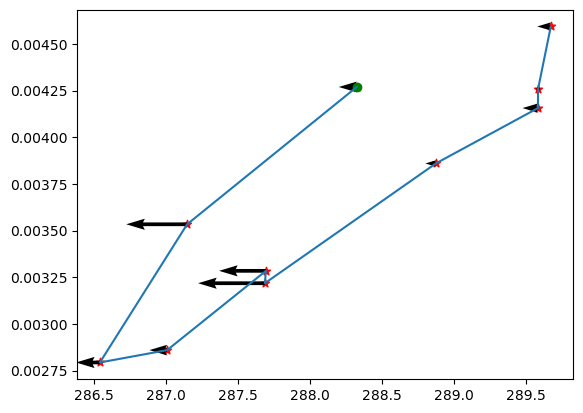

In [67]:
plt.plot(X[0], Y[0], 'go', label='Start')
plt.scatter(X, Y,marker='*', color='r')
plt.plot(X, Y)
plt.quiver(X, Y, dX, dY)

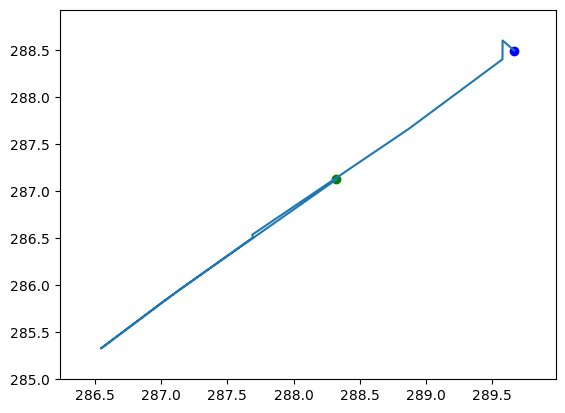

In [54]:

# Create the figure and axis
fig, ax = plt.subplots()

ax.plot(X[0], Y[0], 'go', label='Start')  # Green circle for the start point
ax.plot(X[-1], Y[-1], 'bo', label='End')  # Red circle for the end point
ax.plot(X, Y)

# Plot the vectors (dX_i, dY_i) rooted at (X_i, Y_i)
#ax.quiver(X, Y, dX, dY, angles='xy', scale_units='xy', scale=max(np.max(np.abs(dX)),np.max(np.abs(dY))), color='purple')

# Set the limits of the plot with some margin
x_margin = (max(X) - min(X)) * 0.1
y_margin = (max(Y) - min(Y)) * 0.1
ax.set_xlim(min(X) - x_margin, max(X) + x_margin)
ax.set_ylim(min(Y) - y_margin, max(Y) + y_margin)

# Show the plot
plt.show()

## Spectral Analysis

In [1]:
import diffusionsim.training_utils as tru
import diffusionsim.mydatasets as data
#from pysteps.utils import spectral
import scipy
import scipy.interpolate
import scipy.ndimage

ModuleNotFoundError: No module named 'diffusionsim'

In [ ]:
dconfig = tru.my_dconfig(data_vars='v2', in_notebook=True, climsim_training=True, batch_size=128)
dconfig.train_test_split = [1.0]
dconfig.dataset_type = "climsim_image"
dconfig.source = "gcsfs"
dconfig.dataloader_params.batch_size

In [ ]:
dsets, indices = data.load_dataset(dconfig, log=False)
ds = dsets[0]

In [ ]:
x, y = ds[0]
x.shape, y.shape, x.dtype, x.device

In [ ]:
tmap = y[23, 59, :, :]

def fourier(image):
    spec = np.fft.fft2(image)
    spec = np.fft.fftshift(spec) 
    return(np.log(np.abs(spec)), np.angle(spec))


#upsample_factor = 4  # You can adjust this to achieve the desired resolution
#spec_upsampled = scipy.ndimage.zoom(np.abs(spec), upsample_factor)


In [ ]:
mag, phase = fourier(tmap)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mag, vmin=-5, vmax=11, cmap='viridis')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(phase, vmin=-1*np.pi, vmax=np.pi, cmap=plt.cm.RdBu)
plt.colorbar()

In [ ]:
def RAPSD(image, num_slices=60, num_interp_points=100):
    """
    Computes the Radial Average Power Spectral Density for an input image.
    """
    spec = np.fft.fftshift(np.fft.fft2(image))
    
    # Initialize an array to accumulate power across radial slices
    radial_power = np.zeros(num_interp_points)

    # Loop over angles to take radial slices
    for i in range(num_slices):
        # Angle in radians
        angle = i * (2 * np.pi / num_slices)
        x = np.cos(angle)
        y = np.sin(angle)
        
        # Start and end coordinates for the radial line
        x_start = spec.shape[0] / 2
        y_start = spec.shape[1] / 2
        x_end = x_start + x * (spec.shape[0] / 2)
        y_end = y_start + y * (spec.shape[1] / 2)
        
        # Interpolator to sample the FFT spectrum along the radial line
        interp = scipy.interpolate.RegularGridInterpolator(
            (np.arange(spec.shape[0]), np.arange(spec.shape[1])), np.abs(spec) ** 2 / spec.size)

        # Generate line coordinates and ensure they are within bounds
        x_line = np.linspace(x_start, x_end, num_interp_points, endpoint=False)
        y_line = np.linspace(y_start, y_end, num_interp_points, endpoint=False)
        
        # Clip coordinates to stay within image bounds
        x_line = np.clip(x_line, 0, spec.shape[0] - 1)
        y_line = np.clip(y_line, 0, spec.shape[1] - 1)
        
        coords_line = np.array([x_line, y_line]).T
        
        # Sample and accumulate the power along this radial line
        spec_line = interp(coords_line)
        radial_power += spec_line

    # Average the accumulated power over the number of slices to get the RAPSD
    rapsd = radial_power / num_slices
    return rapsd

In [ ]:
r = RAPSD(tmap)

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

def RAPSDi(images, indices):
    # Define interactive plot function
    def plot_image(index, variable):
        vmap = images[index, variable, :, :]
        plt.plot(np.log(RAPSD(vmap)))
        plt.ylabel("log power")
        plt.xlabel("frequency")
        plt.title(f"Image {indices[index] + 1} - Variable {ds.mlo[variable].item()}")
        plt.show()

    # Create interactive widgets
    n, d = images.shape[:2]
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider)

In [ ]:
indices = np.random.randint(low=0, high=210240, size=100)
images = ds.data.sel(time=indices)
#images.load()

In [ ]:
img = (images - ds.Ymean.mean(dim='ncol')) / ds.Ystd.mean(dim='ncol')
img = img.isel(ncol=ds.permute_indices)
img = img.to_stacked_array(new_dim="mlo", sample_dims=("time", "ncol"))
img = img.transpose("time", "mlo", "ncol")
img = img.data.reshape(-1, 128, ds.height, ds.width)

In [ ]:
plt.imshow(img[5, 59])
plt.colorbar()

In [ ]:
RAPSDi(img, indices)

In [ ]:
for k in range(num_displayed_examples):
  rapsd, frequencies = spectral.rapsd(images[k, ..., 1], fft_method=np.fft, return_freq=True)
  plt.subplot(2, 4, 4 + k + 1)
  plt.plot(frequencies[1:], rapsd[1:], c='red', marker='o', markersize=3)  # Chop off the DC component.
  plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('frequency')
  if k == 0:
    plt.ylabel('power')